In [10]:
import pandas as pd
import os

path_data = 'C:/Users/skar/Box/saura_self/Proj - Water tool analysis/data/output'
fname = 'survey_effluent.xlsx'
sname = 'Sheet1'

path_out = 'C:/Users/skar/Box/saura_self/Proj - Water tool analysis/data/output'

df = pd.read_excel(os.path.join(path_data, fname), sheet_name=sname)

df = df[['CWNS_ID', 
         'ACTUAL_FLOW_AVG', 
         'PREDICTED_WRRF_TT_CODE', 
         'Electricity_purchased_from_utility_MJ_per_m3', 
         'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3', 
         'Biogas_generated_onsite_MJ_per_m3', 
         'Electricity_produced_onsite_kWh_per_m3',
         'Total energy purchased_MJ_per_m3_survey']]
print(df.head())

       CWNS_ID  ACTUAL_FLOW_AVG PREDICTED_WRRF_TT_CODE  \
0  17000721001       678.468493                   *AG2   
1  26000596001       510.000000                *B6, *B   
2  17000721009       237.000000                   *AG2   
3  11000001001       295.260000                 *AEF2e   
4  29001023002       112.500000                   *AE5   

   Electricity_purchased_from_utility_MJ_per_m3  \
0                                      1.082009   
1                                      0.831904   
2                                      1.260028   
3                                      1.710234   
4                                      0.361254   

   NATURAL_GAS_PURCHASED_onsite_MJ_per_m3  Biogas_generated_onsite_MJ_per_m3  \
0                                0.015465                           0.971405   
1                                1.351802                           0.000000   
2                                0.028968                           0.523650   
3                       

FILTERING: Dropping rows with blank PREDICTED_WRRF_TT_CODE
Number of rows dropped: 1

CWNS_IDs of dropped rows:
  - 36008024001
Remaining rows after filtering: 36

Replacing '*' with 'P' in PREDICTED_WRRF_TT_CODE (36 rows affected)
Replacement complete.

Unique characters found: ['1', '2', '5', '6', 'A', 'B', 'C', 'E', 'F', 'G', 'P', 'e']

Encoded DataFrame (first few rows):
       CWNS_ID  ACTUAL_FLOW_AVG PREDICTED_WRRF_TT_CODE  \
0  17000721001       678.468493                   PAG2   
1  26000596001       510.000000                PB6, PB   
2  17000721009       237.000000                   PAG2   
3  11000001001       295.260000                 PAEF2e   
4  29001023002       112.500000                   PAE5   

   Electricity_purchased_from_utility_MJ_per_m3  \
0                                      1.082009   
1                                      0.831904   
2                                      1.260028   
3                                      1.710234   
4                 

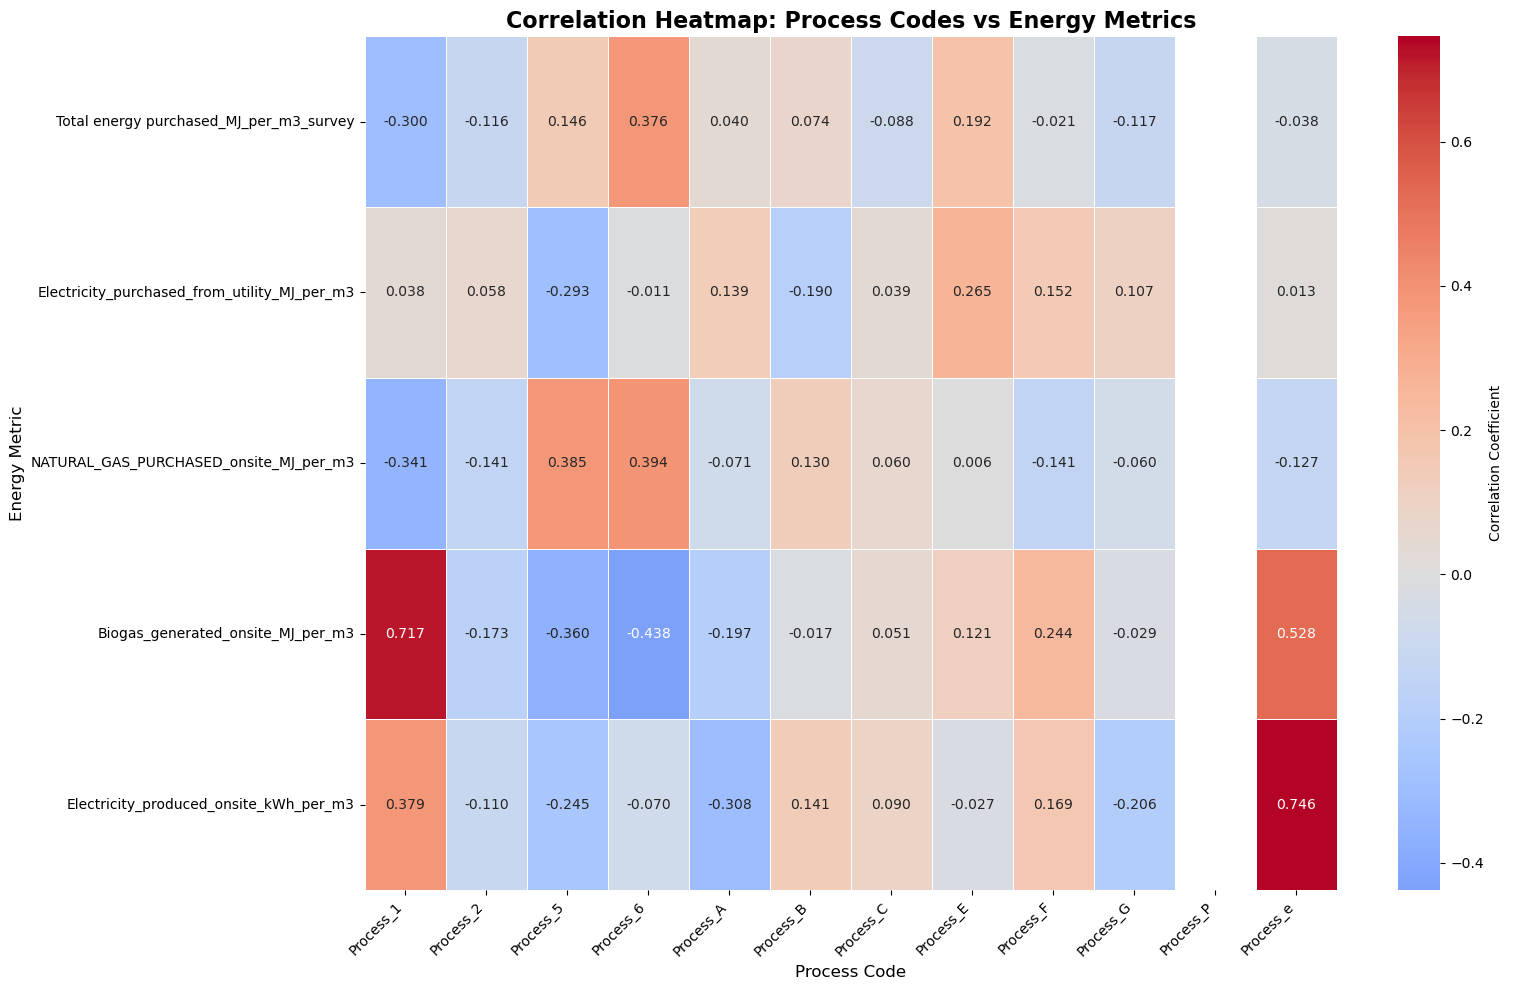

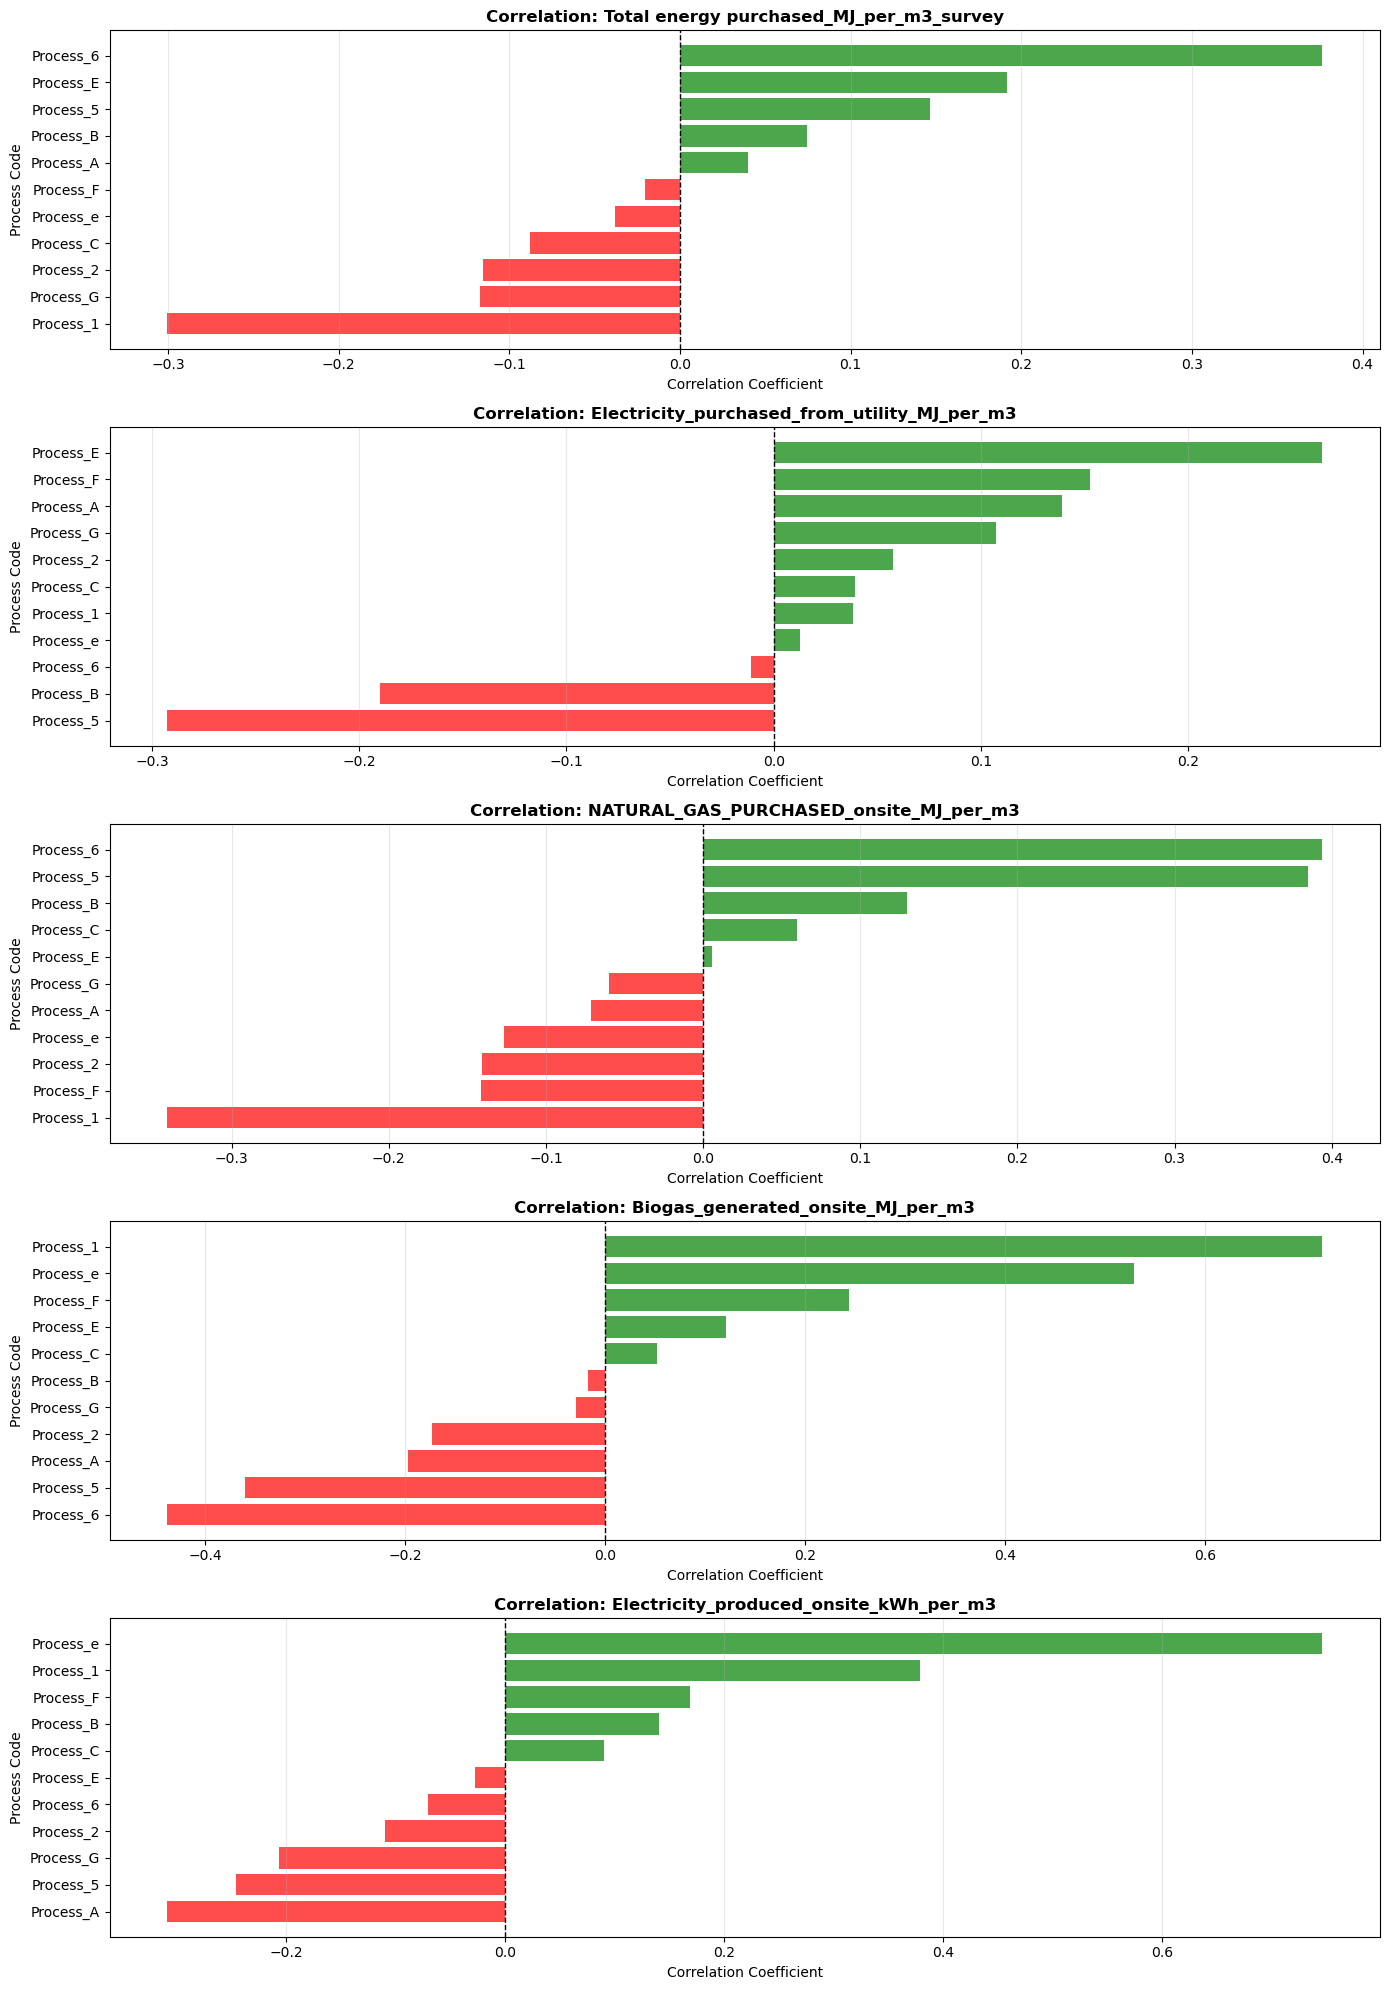

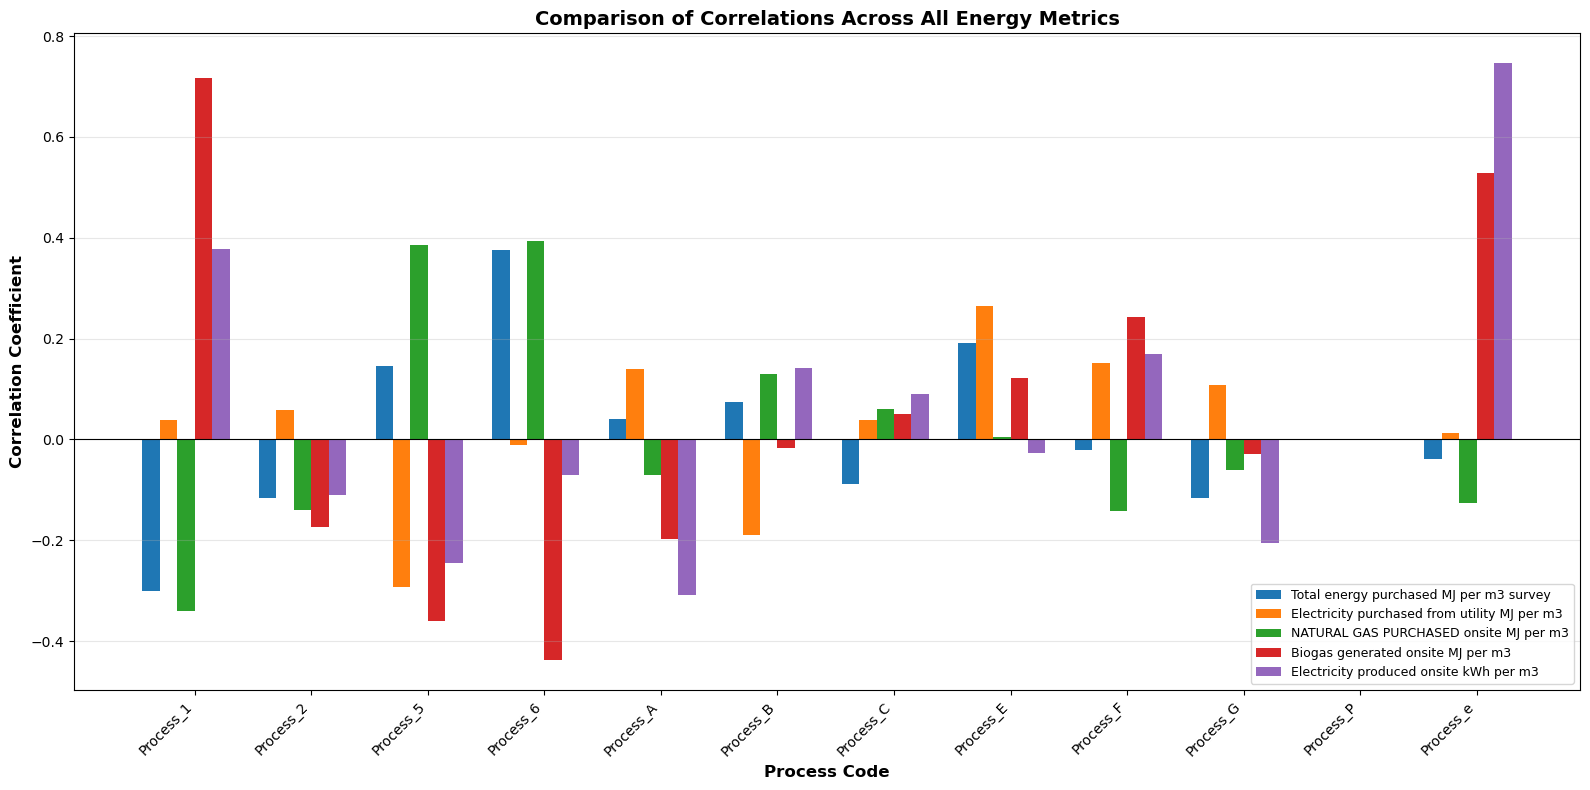

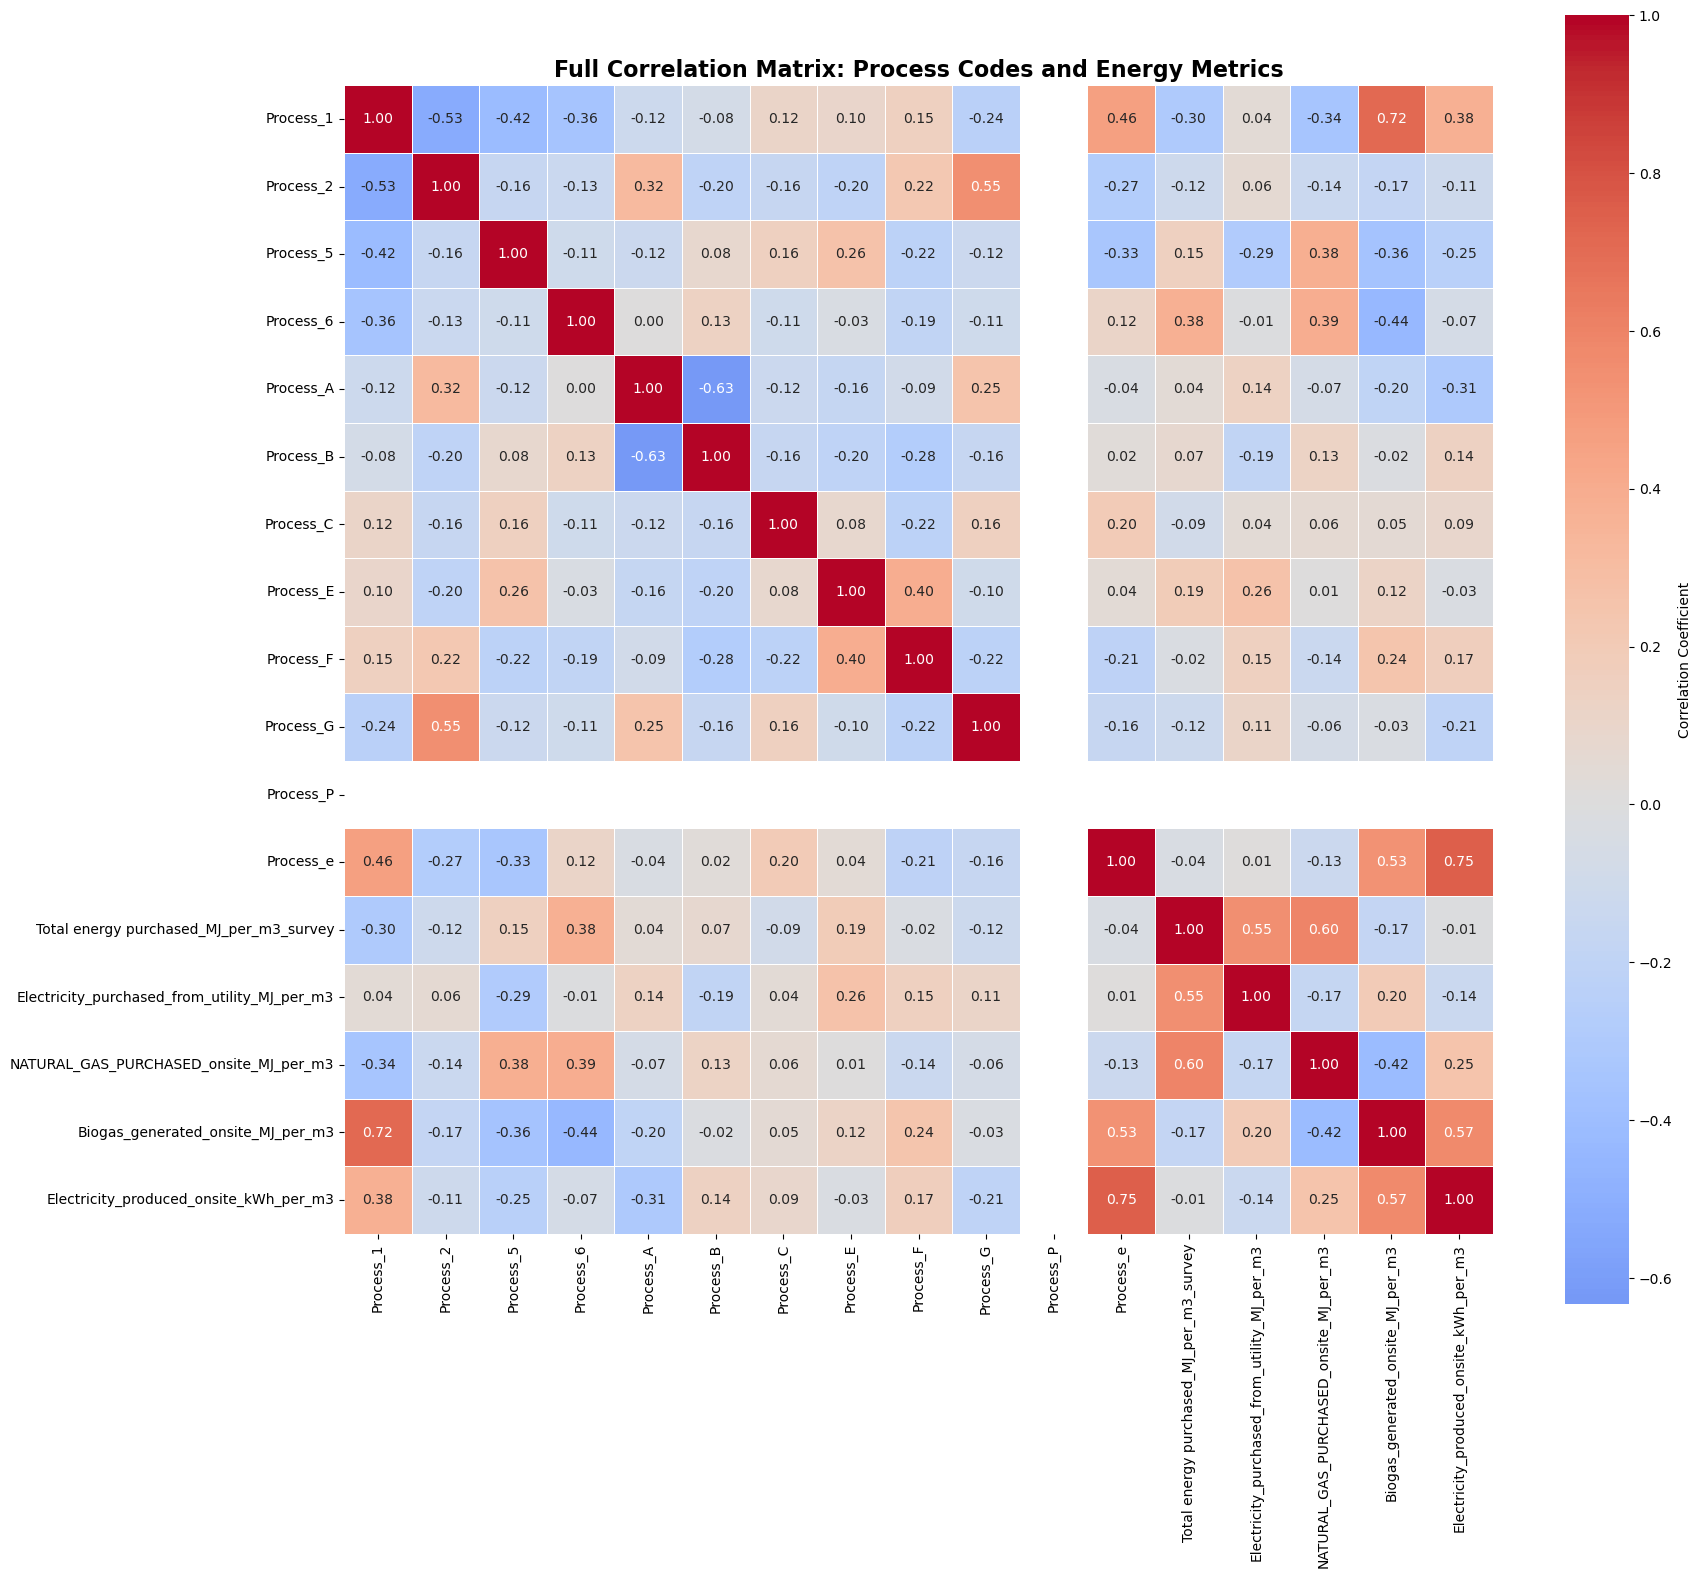


ANALYSIS COMPLETE!

Files saved:
- encoded_data.csv: Full dataset with binary process columns
- correlation_results_all_metrics.csv: Correlation coefficients matrix
- correlation_significance_results.csv: Detailed results with p-values
- correlation_analysis_summary.txt: Text summary report
- correlation_heatmap_all_metrics.png: Heatmap visualization
- correlation_bars_all_metrics.png: Individual bar charts
- correlation_comparison_grouped.png: Grouped comparison chart
- full_correlation_matrix.png: Complete correlation matrix

Summary of Process Columns:
Process_1: 21 occurrences (58.3%)
Process_2: 6 occurrences (16.7%)
Process_5: 4 occurrences (11.1%)
Process_6: 3 occurrences (8.3%)
Process_A: 24 occurrences (66.7%)
Process_B: 6 occurrences (16.7%)
Process_C: 4 occurrences (11.1%)
Process_E: 14 occurrences (38.9%)
Process_F: 10 occurrences (27.8%)
Process_G: 4 occurrences (11.1%)
Process_P: 36 occurrences (100.0%)
Process_e: 17 occurrences (47.2%)


In [11]:
# Perform Spearman correlation analysis between process codes and energy metrics

# Perform Spearman correlation analysis between process codes and energy metrics

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


# =============================================================================
# FILTER: Drop rows where PREDICTED_WRRF_TT_CODE is blank
# =============================================================================
# Identify rows where PREDICTED_WRRF_TT_CODE is NaN, empty string, or whitespace-only
blank_mask = (
    df['PREDICTED_WRRF_TT_CODE'].isna() |
    df['PREDICTED_WRRF_TT_CODE'].astype(str).str.strip().eq('') |
    df['PREDICTED_WRRF_TT_CODE'].astype(str).str.strip().eq('nan')
)

# Extract the rows that will be dropped
dropped_rows = df[blank_mask]
num_dropped = len(dropped_rows)

print("=" * 80)
print(f"FILTERING: Dropping rows with blank PREDICTED_WRRF_TT_CODE")
print("=" * 80)
print(f"Number of rows dropped: {num_dropped}")

if num_dropped > 0:
    print(f"\nCWNS_IDs of dropped rows:")
    for cwns_id in dropped_rows['CWNS_ID'].values:
        print(f"  - {cwns_id}")
else:
    print("No rows had blank PREDICTED_WRRF_TT_CODE.")

print("=" * 80)

# Apply the filter — keep only rows where PREDICTED_WRRF_TT_CODE is NOT blank
df = df[~blank_mask].copy()
print(f"Remaining rows after filtering: {len(df)}\n")


# =============================================================================
# REPLACE '*' with 'P' in PREDICTED_WRRF_TT_CODE before any encoding
# =============================================================================
# This avoids issues with '*' being treated as a regex wildcard or causing
# NaN results during correlation analysis.
asterisk_count = df['PREDICTED_WRRF_TT_CODE'].str.contains(r'\*', na=False).sum()
print(f"Replacing '*' with 'P' in PREDICTED_WRRF_TT_CODE ({asterisk_count} rows affected)")
df['PREDICTED_WRRF_TT_CODE'] = df['PREDICTED_WRRF_TT_CODE'].str.replace('*', 'P', regex=False)
print(f"Replacement complete.\n")


# Define all energy columns for analysis
energy_columns = [
    'Total energy purchased_MJ_per_m3_survey',
    'Electricity_purchased_from_utility_MJ_per_m3',
    'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3',
    'Biogas_generated_onsite_MJ_per_m3',
    'Electricity_produced_onsite_kWh_per_m3'
]

# Step 1: Extract all unique characters from PREDICTED_WRRF_TT_CODE column
def extract_unique_characters(column):
    """
    Extract all unique characters from a column containing comma-separated values.
    Since '*' has been replaced with 'P', no special handling is needed.
    """
    all_chars = set()
    for value in column.dropna():
        # Remove spaces and split by comma
        chars = str(value).replace(' ', '').split(',')
        for char in chars:
            # Add each individual character
            all_chars.update(list(char))
    return sorted(all_chars)

# Get unique characters
unique_chars = extract_unique_characters(df['PREDICTED_WRRF_TT_CODE'])
print(f"Unique characters found: {unique_chars}")

# Step 2: Create binary columns for each unique character
def create_binary_columns(df, column_name, unique_chars):
    """
    Create binary columns (0/1) for each unique character.
    Since '*' has already been replaced with 'P', all characters are
    standard alphanumeric and no special handling is required.
    """
    df_encoded = df.copy()
    
    for char in unique_chars:
        col_name = f'Process_{char}'
        
        # Check if character exists in the original column
        df_encoded[col_name] = df_encoded[column_name].apply(
            lambda x: 1 if pd.notna(x) and char in str(x).replace(',', '').replace(' ', '') else 0
        )
    
    return df_encoded

# Apply encoding
df_encoded = create_binary_columns(df, 'PREDICTED_WRRF_TT_CODE', unique_chars)

# Display the encoded dataframe
print("\nEncoded DataFrame (first few rows):")
print(df_encoded.head())

# Step 3: Get all process columns
process_columns = [f'Process_{char}' for char in unique_chars]

# Step 4: Comprehensive correlation analysis for all energy columns
all_correlations = {}

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        correlations = {}
        for proc_col in process_columns:
            # Remove rows with NaN values
            valid_data = df_encoded[[proc_col, energy_col]].dropna()
            if len(valid_data) > 2:
                corr, _ = spearmanr(valid_data[proc_col], valid_data[energy_col])
                correlations[proc_col] = corr
            else:
                correlations[proc_col] = np.nan
        all_correlations[energy_col] = correlations

# Create comprehensive correlation dataframe
corr_results = pd.DataFrame(all_correlations)
corr_results.index.name = 'Process_Code'
print("\nComprehensive Correlation Analysis Results:")
print(corr_results)

# Step 5: Statistical significance testing with p-values
print("\n" + "="*80)
print("DETAILED CORRELATION ANALYSIS WITH P-VALUES")
print("="*80)

significance_results = []

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        print(f"\n{energy_col}:")
        print("-" * 80)
        for proc_col in process_columns:
            valid_data = df_encoded[[proc_col, energy_col]].dropna()
            if len(valid_data) > 2:
                corr_coef, p_value = spearmanr(valid_data[proc_col], valid_data[energy_col])
                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
                print(f"  {proc_col:25s}: r = {corr_coef:7.4f}, p = {p_value:.4f} {significance}")
                
                significance_results.append({
                    'Energy_Metric': energy_col,
                    'Process_Code': proc_col,
                    'Correlation': corr_coef,
                    'P_Value': p_value,
                    'Significant': p_value < 0.05
                })

# Create significance dataframe
sig_df = pd.DataFrame(significance_results)

# Step 6: Visualization 1 - Heatmap of all correlations
plt.figure(figsize=(16, 10))
sns.heatmap(corr_results.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=False, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap: Process Codes vs Energy Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Process Code', fontsize=12)
plt.ylabel('Energy Metric', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(path_out, 'correlation_heatmap_all_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Visualization 2 - Individual bar charts for each energy metric
fig, axes = plt.subplots(len(energy_columns), 1, figsize=(14, 4*len(energy_columns)))
if len(energy_columns) == 1:
    axes = [axes]

for idx, energy_col in enumerate(energy_columns):
    if energy_col in df_encoded.columns:
        corr_data = corr_results[energy_col].dropna().sort_values(ascending=True)
        
        colors = ['red' if x < 0 else 'green' for x in corr_data.values]
        axes[idx].barh(corr_data.index, corr_data.values, color=colors, alpha=0.7)
        axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1)
        axes[idx].set_xlabel('Correlation Coefficient', fontsize=10)
        axes[idx].set_ylabel('Process Code', fontsize=10)
        axes[idx].set_title(f'Correlation: {energy_col}', fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path_out, 'correlation_bars_all_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 8: Visualization 3 - Grouped bar chart comparison
corr_results_plot = corr_results.T
x = np.arange(len(process_columns))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 8))
for i, energy_col in enumerate(energy_columns):
    if energy_col in corr_results_plot.index:
        offset = width * (i - len(energy_columns)/2)
        values = [corr_results_plot.loc[energy_col, col] if col in corr_results_plot.columns else 0 
                  for col in process_columns]
        ax.bar(x + offset, values, width, label=energy_col.replace('_', ' '))

ax.set_xlabel('Process Code', fontsize=12, fontweight='bold')
ax.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Correlations Across All Energy Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(process_columns, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.legend(loc='best', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(path_out, 'correlation_comparison_grouped.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 9: Create full correlation matrix including all variables
all_analysis_columns = process_columns + [col for col in energy_columns if col in df_encoded.columns]
full_corr_matrix = df_encoded[all_analysis_columns].corr(method='spearman')

plt.figure(figsize=(18, 16))
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Full Correlation Matrix: Process Codes and Energy Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(path_out, 'full_correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 10: Export all results
# Save encoded dataframe
df_encoded.to_csv(os.path.join(path_out, 'encoded_data.csv'), index=False)

# Save correlation results
corr_results.to_csv(os.path.join(path_out, 'correlation_results_all_metrics.csv'), index=False)

# Save significance results
sig_df.to_csv(os.path.join(path_out, 'correlation_significance_results.csv'), index=False)

# Create summary report
with open(os.path.join(path_out, 'correlation_analysis_summary.txt'), 'w') as f:
    f.write("CORRELATION ANALYSIS SUMMARY REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Total number of records (after filtering): {len(df_encoded)}\n")
    f.write(f"Number of rows dropped (blank PREDICTED_WRRF_TT_CODE): {num_dropped}\n")
    f.write(f"Note: '*' in PREDICTED_WRRF_TT_CODE was replaced with 'P' before encoding.\n\n")
    f.write(f"Number of process codes identified: {len(process_columns)}\n")
    f.write(f"Process codes: {', '.join(process_columns)}\n\n")
    
    f.write("Process Code Frequencies:\n")
    f.write("-"*80 + "\n")
    for col in process_columns:
        count = df_encoded[col].sum()
        percentage = (count / len(df_encoded)) * 100
        f.write(f"{col:25s}: {count:5d} occurrences ({percentage:5.1f}%)\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("CORRELATION SUMMARY\n")
    f.write("="*80 + "\n\n")
    
    for energy_col in energy_columns:
        if energy_col in df_encoded.columns:
            f.write(f"\n{energy_col}:\n")
            f.write("-"*80 + "\n")
            energy_corrs = sig_df[sig_df['Energy_Metric'] == energy_col].sort_values('Correlation', ascending=False)
            for _, row in energy_corrs.iterrows():
                sig_marker = "***" if row['P_Value'] < 0.001 else "**" if row['P_Value'] < 0.01 else "*" if row['P_Value'] < 0.05 else ""
                f.write(f"  {row['Process_Code']:25s}: r = {row['Correlation']:7.4f}, p = {row['P_Value']:.4f} {sig_marker}\n")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nFiles saved:")
print("- encoded_data.csv: Full dataset with binary process columns")
print("- correlation_results_all_metrics.csv: Correlation coefficients matrix")
print("- correlation_significance_results.csv: Detailed results with p-values")
print("- correlation_analysis_summary.txt: Text summary report")
print("- correlation_heatmap_all_metrics.png: Heatmap visualization")
print("- correlation_bars_all_metrics.png: Individual bar charts")
print("- correlation_comparison_grouped.png: Grouped comparison chart")
print("- full_correlation_matrix.png: Complete correlation matrix")

print("\nSummary of Process Columns:")
for col in process_columns:
    count = df_encoded[col].sum()
    percentage = (count / len(df_encoded)) * 100
    print(f"{col}: {count} occurrences ({percentage:.1f}%)")


In [ ]:
# With multiple correlation methods and comprehensive analysis, we can now identify which process codes are most strongly associated with each energy metric, and whether those associations are statistically significant. This will help guide further analysis and potential interventions based on the identified relationships.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.stats import shapiro, normaltest, boxcox
from scipy.special import inv_boxcox
import warnings
warnings.filterwarnings('ignore')

# Define all energy columns for analysis
energy_columns = [
    'Total energy purchased_MJ_per_m3_survey',
    'Electricity_purchased_from_utility_MJ_per_m3',
    'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3',
    'Biogas_generated_onsite_MJ_per_m3',
    'Electricity_produced_onsite_kWh_per_m3'
]

# Step 1: Extract unique characters and create binary columns
def extract_unique_characters(column):
    all_chars = set()
    for value in column.dropna():
        chars = str(value).replace(' ', '').split(',')
        for char in chars:
            all_chars.update(list(char))
    return sorted(all_chars)

def create_binary_columns(df, column_name, unique_chars):
    df_encoded = df.copy()
    for char in unique_chars:
        if char == '*':
            col_name = 'Process_asterisk'
        else:
            col_name = f'Process_{char}'
        df_encoded[col_name] = df_encoded[column_name].apply(
            lambda x: 1 if pd.notna(x) and char in str(x).replace(',', '').replace(' ', '') else 0
        )
    return df_encoded

unique_chars = extract_unique_characters(df['PREDICTED_WRRF_TT_CODE'])
df_encoded = create_binary_columns(df, 'PREDICTED_WRRF_TT_CODE', unique_chars)

process_columns = []
for char in unique_chars:
    if char == '*':
        process_columns.append('Process_asterisk')
    else:
        process_columns.append(f'Process_{char}')

# Step 2: Test for normality and visualize distributions
print("="*80)
print("NORMALITY TESTS FOR ENERGY VARIABLES")
print("="*80)

normality_results = []

fig, axes = plt.subplots(len(energy_columns), 3, figsize=(18, 4*len(energy_columns)))
if len(energy_columns) == 1:
    axes = axes.reshape(1, -1)

for idx, energy_col in enumerate(energy_columns):
    if energy_col in df_encoded.columns:
        data = df_encoded[energy_col].dropna()
        
        # Normality tests
        shapiro_stat, shapiro_p = shapiro(data) if len(data) <= 5000 else (np.nan, np.nan)
        dagostino_stat, dagostino_p = normaltest(data) if len(data) >= 8 else (np.nan, np.nan)
        
        # Calculate skewness and kurtosis
        skewness = data.skew()
        kurtosis = data.kurtosis()
        
        normality_results.append({
            'Variable': energy_col,
            'N': len(data),
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Shapiro_p': shapiro_p,
            'DAgostino_p': dagostino_p,
            'Normal': 'No' if (shapiro_p < 0.05 or dagostino_p < 0.05) else 'Possibly'
        })
        
        print(f"\n{energy_col}:")
        print(f"  Skewness: {skewness:.3f} {'(Right-skewed)' if skewness > 0.5 else '(Approximately symmetric)' if abs(skewness) <= 0.5 else '(Left-skewed)'}")
        print(f"  Kurtosis: {kurtosis:.3f}")
        if not np.isnan(shapiro_p):
            print(f"  Shapiro-Wilk p-value: {shapiro_p:.4f} {'(Non-normal)' if shapiro_p < 0.05 else '(Normal)'}")
        if not np.isnan(dagostino_p):
            print(f"  D'Agostino p-value: {dagostino_p:.4f} {'(Non-normal)' if dagostino_p < 0.05 else '(Normal)'}")
        
        # Histogram
        axes[idx, 0].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[idx, 0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
        axes[idx, 0].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
        axes[idx, 0].set_xlabel('Value')
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].set_title(f'Distribution: {energy_col}\nSkewness: {skewness:.2f}')
        axes[idx, 0].legend()
        axes[idx, 0].grid(alpha=0.3)
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(data, dist="norm", plot=axes[idx, 1])
        axes[idx, 1].set_title(f'Q-Q Plot: {energy_col}')
        axes[idx, 1].grid(alpha=0.3)
        
        # Box plot
        axes[idx, 2].boxplot(data, vert=True)
        axes[idx, 2].set_ylabel('Value')
        axes[idx, 2].set_title(f'Box Plot: {energy_col}')
        axes[idx, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path_out, 'distribution_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save normality results
normality_df = pd.DataFrame(normality_results)
normality_df.to_csv(os.path.join(path_out, 'normality_test_results.csv'), index=False)
print("\n" + normality_df.to_string())

# Step 3: Apply transformations to skewed variables
print("\n" + "="*80)
print("APPLYING TRANSFORMATIONS TO SKEWED VARIABLES")
print("="*80)

df_transformed = df_encoded.copy()
transformation_info = {}

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        data = df_encoded[energy_col].dropna()
        skewness = data.skew()
        
        if abs(skewness) > 0.5:  # Apply transformation if skewed
            print(f"\n{energy_col} (Skewness: {skewness:.3f}):")
            
            # Log transformation
            log_col = f"{energy_col}_log"
            df_transformed[log_col] = np.log1p(df_encoded[energy_col])  # log(1+x) to handle zeros
            log_skew = df_transformed[log_col].dropna().skew()
            print(f"  Log transform skewness: {log_skew:.3f}")
            
            # Square root transformation
            sqrt_col = f"{energy_col}_sqrt"
            df_transformed[sqrt_col] = np.sqrt(df_encoded[energy_col])
            sqrt_skew = df_transformed[sqrt_col].dropna().skew()
            print(f"  Sqrt transform skewness: {sqrt_skew:.3f}")
            
            # Box-Cox transformation (only for positive values)
            if (data > 0).all():
                boxcox_col = f"{energy_col}_boxcox"
                transformed_data, lambda_param = boxcox(data)
                df_transformed.loc[data.index, boxcox_col] = transformed_data
                boxcox_skew = df_transformed[boxcox_col].dropna().skew()
                print(f"  Box-Cox transform skewness: {boxcox_skew:.3f} (λ={lambda_param:.3f})")
                
                transformation_info[energy_col] = {
                    'method': 'boxcox',
                    'lambda': lambda_param,
                    'column': boxcox_col,
                    'original_skew': skewness,
                    'transformed_skew': boxcox_skew
                }
            else:
                # Use log if Box-Cox not applicable
                transformation_info[energy_col] = {
                    'method': 'log',
                    'column': log_col,
                    'original_skew': skewness,
                    'transformed_skew': log_skew
                }
            
            # Choose best transformation (closest to 0 skewness)
            best_transform = min(
                [('log', log_skew, log_col), ('sqrt', sqrt_skew, sqrt_col)] + 
                ([('boxcox', boxcox_skew, boxcox_col)] if (data > 0).all() else []),
                key=lambda x: abs(x[1])
            )
            print(f"  → Best transformation: {best_transform[0]} (skewness: {best_transform[1]:.3f})")

# Step 4: Comprehensive correlation analysis with multiple methods
def calculate_correlations(df, x_col, y_col, min_n=10):
    """Calculate Pearson, Spearman, and Kendall correlations with p-values"""
    valid_data = df[[x_col, y_col]].dropna()
    
    if len(valid_data) < min_n:
        return None
    
    x = valid_data[x_col]
    y = valid_data[y_col]
    
    # Pearson
    pearson_r, pearson_p = pearsonr(x, y)
    
    # Spearman
    spearman_r, spearman_p = spearmanr(x, y)
    
    # Kendall (can be slow for large datasets)
    if len(valid_data) < 1000:
        kendall_r, kendall_p = kendalltau(x, y)
    else:
        kendall_r, kendall_p = np.nan, np.nan
    
    return {
        'n': len(valid_data),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'kendall_r': kendall_r,
        'kendall_p': kendall_p
    }

# Perform correlation analysis
print("\n" + "="*80)
print("COMPREHENSIVE CORRELATION ANALYSIS")
print("="*80)

all_correlation_results = []

for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS FOR: {energy_col}")
    print(f"{'='*80}")
    
    # Determine which version to use
    if energy_col in transformation_info:
        trans_col = transformation_info[energy_col]['column']
        print(f"Using transformed variable: {trans_col}")
        print(f"Transformation: {transformation_info[energy_col]['method']}")
        analysis_col = trans_col
        use_transformed = True
    else:
        analysis_col = energy_col
        use_transformed = False
        print("Using original variable (approximately normal)")
    
    print(f"\n{'Process Code':<25} {'N':<6} {'Pearson r':<12} {'p-value':<10} {'Spearman r':<12} {'p-value':<10} {'Recommendation'}")
    print("-"*110)
    
    for proc_col in process_columns:
        # Original data correlations
        orig_results = calculate_correlations(df_encoded, proc_col, energy_col)
        
        # Transformed data correlations (if applicable)
        if use_transformed:
            trans_results = calculate_correlations(df_transformed, proc_col, analysis_col)
        else:
            trans_results = orig_results
        
        if trans_results is None:
            continue
        
        # Determine recommendation
        if abs(trans_results['spearman_r'] - trans_results['pearson_r']) > 0.1:
            recommendation = "Use Spearman (non-linear)"
        elif use_transformed:
            recommendation = "Use Pearson on transformed"
        else:
            recommendation = "Use Pearson"
        
        # Determine significance
        sig_marker = ""
        if trans_results['spearman_p'] < 0.001:
            sig_marker = "***"
        elif trans_results['spearman_p'] < 0.01:
            sig_marker = "**"
        elif trans_results['spearman_p'] < 0.05:
            sig_marker = "*"
        
        print(f"{proc_col:<25} {trans_results['n']:<6} "
              f"{trans_results['pearson_r']:>7.4f} {sig_marker:<4} {trans_results['pearson_p']:>8.4f}  "
              f"{trans_results['spearman_r']:>7.4f} {sig_marker:<4} {trans_results['spearman_p']:>8.4f}  "
              f"{recommendation}")
        
        all_correlation_results.append({
            'Energy_Variable': energy_col,
            'Process_Code': proc_col,
            'N': trans_results['n'],
            'Pearson_r': trans_results['pearson_r'],
            'Pearson_p': trans_results['pearson_p'],
            'Spearman_r': trans_results['spearman_r'],
            'Spearman_p': trans_results['spearman_p'],
            'Kendall_r': trans_results['kendall_r'],
            'Kendall_p': trans_results['kendall_p'],
            'Transformed': use_transformed,
            'Recommendation': recommendation
        })

# Save comprehensive results
results_df = pd.DataFrame(all_correlation_results)
results_df.to_csv(os.path.join(path_data, 'comprehensive_correlation_results.csv'), index=False)

# Step 5: Comparison visualization
print("\n" + "="*80)
print("CREATING COMPARISON VISUALIZATIONS")
print("="*80)

# Compare Pearson vs Spearman for each energy variable
for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    energy_results = results_df[results_df['Energy_Variable'] == energy_col].copy()
    energy_results = energy_results.sort_values('Spearman_r', ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson vs Spearman comparison
    x = np.arange(len(energy_results))
    width = 0.35
    
    ax1.barh(x - width/2, energy_results['Pearson_r'], width, label='Pearson', alpha=0.8)
    ax1.barh(x + width/2, energy_results['Spearman_r'], width, label='Spearman', alpha=0.8)
    ax1.set_yticks(x)
    ax1.set_yticklabels(energy_results['Process_Code'])
    ax1.set_xlabel('Correlation Coefficient')
    ax1.set_title(f'Pearson vs Spearman Correlation\n{energy_col}')
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Scatter plot: Pearson vs Spearman
    ax2.scatter(energy_results['Pearson_r'], energy_results['Spearman_r'], s=100, alpha=0.6)
    
    # Add diagonal line (perfect agreement)
    lims = [
        min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
        max(ax2.get_xlim()[1], ax2.get_ylim()[1])
    ]
    ax2.plot(lims, lims, 'r--', alpha=0.5, label='Perfect Agreement')
    
    # Annotate points
    for _, row in energy_results.iterrows():
        if abs(row['Pearson_r'] - row['Spearman_r']) > 0.1:  # Only label divergent points
            ax2.annotate(row['Process_Code'], 
                        (row['Pearson_r'], row['Spearman_r']),
                        fontsize=8, alpha=0.7)
    
    ax2.set_xlabel('Pearson Correlation')
    ax2.set_ylabel('Spearman Correlation')
    ax2.set_title('Pearson vs Spearman Agreement')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f'correlation_comparison_{energy_col}.png'), dpi=300, bbox_inches='tight')
    plt.close()

# Step 6: Create heatmaps for Spearman correlations (recommended for skewed data)
spearman_matrix = pd.DataFrame(index=process_columns)

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        spearman_values = []
        for proc_col in process_columns:
            result = results_df[
                (results_df['Energy_Variable'] == energy_col) & 
                (results_df['Process_Code'] == proc_col)
            ]
            if len(result) > 0:
                spearman_values.append(result.iloc[0]['Spearman_r'])
            else:
                spearman_values.append(np.nan)
        spearman_matrix[energy_col] = spearman_values

plt.figure(figsize=(16, 10))
sns.heatmap(spearman_matrix.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=False, linewidths=0.5, 
            cbar_kws={'label': 'Spearman Correlation Coefficient'})
plt.title('Spearman Correlation Heatmap (Recommended for Skewed Data)\nProcess Codes vs Energy Metrics', 
          fontsize=16, fontweight='bold')
plt.xlabel('Process Code', fontsize=12)
plt.ylabel('Energy Metric', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(path_out, 'spearman_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Summary report
print("\n" + "="*80)
print("ANALYSIS SUMMARY AND RECOMMENDATIONS")
print("="*80)

summary_report = []

for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    energy_results = results_df[results_df['Energy_Variable'] == energy_col]
    
    # Count significant correlations
    sig_pearson = len(energy_results[energy_results['Pearson_p'] < 0.05])
    sig_spearman = len(energy_results[energy_results['Spearman_p'] < 0.05])
    
    # Find strongest correlations
    strongest_pearson = energy_results.loc[energy_results['Pearson_r'].abs().idxmax()]
    strongest_spearman = energy_results.loc[energy_results['Spearman_r'].abs().idxmax()]
    
    # Check for large discrepancies
    energy_results['discrepancy'] = abs(energy_results['Pearson_r'] - energy_results['Spearman_r'])
    max_discrepancy = energy_results['discrepancy'].max()
    
    summary_report.append({
        'Energy_Variable': energy_col,
        'Significant_Pearson': sig_pearson,
        'Significant_Spearman': sig_spearman,
        'Strongest_Pearson_Process': strongest_pearson['Process_Code'],
        'Strongest_Pearson_r': strongest_pearson['Pearson_r'],
        'Strongest_Spearman_Process': strongest_spearman['Process_Code'],
        'Strongest_Spearman_r': strongest_spearman['Spearman_r'],
        'Max_Discrepancy': max_discrepancy,
        'Recommendation': 'Use Spearman' if max_discrepancy > 0.1 else 'Either method acceptable'
    })
    
    print(f"\n{energy_col}:")
    print(f"  Significant correlations (Pearson): {sig_pearson}/{len(energy_results)}")
    print(f"  Significant correlations (Spearman): {sig_spearman}/{len(energy_results)}")
    print(f"  Strongest Pearson: {strongest_pearson['Process_Code']} (r={strongest_pearson['Pearson_r']:.3f})")
    print(f"  Strongest Spearman: {strongest_spearman['Process_Code']} (r={strongest_spearman['Spearman_r']:.3f})")
    print(f"  Max discrepancy: {max_discrepancy:.3f}")
    print(f"  → RECOMMENDATION: {summary_report[-1]['Recommendation']}")

summary_df = pd.DataFrame(summary_report)
summary_df.to_csv(os.path.join(path_out, 'correlation_analysis_summary.csv'), index=False)

print("\n" + "="*80)
print("FILES SAVED:")
print("="*80)
print("- distribution_analysis.png: Distribution diagnostics")
print("- normality_test_results.csv: Normality test statistics")
print("- comprehensive_correlation_results.csv: All correlation methods")
print("- correlation_comparison_[variable].png: Method comparison plots")
print("- spearman_correlation_heatmap.png: Recommended correlations")
print("- correlation_analysis_summary.csv: Summary and recommendations")

print("\n" + "="*80)
print("FINAL RECOMMENDATION:")
print("="*80)
print("Given your right-skewed distributions:")
print("1. PRIMARY: Use Spearman correlation for all analyses")
print("2. ALTERNATIVE: Use Pearson on transformed data (log/Box-Cox)")
print("3. Report both methods for transparency")
print("4. Focus on Spearman for interpretation and decision-making")
print("="*80)

NORMALITY TESTS FOR ENERGY VARIABLES

Total energy purchased_MJ_per_m3_survey:
  Skewness: 4.600 (Right-skewed)
  Kurtosis: 22.198
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0000 (Non-normal)

Electricity_purchased_from_utility_MJ_per_m3:
  Skewness: 1.340 (Right-skewed)
  Kurtosis: 3.854
  Shapiro-Wilk p-value: 0.0055 (Non-normal)
  D'Agostino p-value: 0.0003 (Non-normal)

NATURAL_GAS_PURCHASED_onsite_MJ_per_m3:
  Skewness: 4.460 (Right-skewed)
  Kurtosis: 21.486
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0000 (Non-normal)

Biogas_generated_onsite_MJ_per_m3:
  Skewness: 0.704 (Right-skewed)
  Kurtosis: 0.637
  Shapiro-Wilk p-value: 0.0095 (Non-normal)
  D'Agostino p-value: 0.1491 (Normal)

Electricity_produced_onsite_kWh_per_m3:
  Skewness: 1.706 (Right-skewed)
  Kurtosis: 1.877
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0006 (Non-normal)
